In [1]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.5/511.5 kB 17.5 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.1/774.1 kB 16.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00


In [2]:
import os

# Find the ratings file wherever PyG put it
for root, dirs, files in os.walk('data'):
    for f in files:
        print(os.path.join(root, f))

In [3]:
import subprocess
result = subprocess.run(['find', '/', '-name', 'ratings.dat', '-type', 'f'],
                       capture_output=True, text=True, timeout=30)
print(result.stdout)


In [4]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.datasets import MovieLens1M

# Re-run dataset download (safe to re-run, uses cache)
dataset = MovieLens1M(root='data/MovieLens1M')

# Correct path — PyG extracts here
ratings_path = '/content/data/MovieLens1M/raw/ratings.dat'

df = pd.read_csv(ratings_path, sep='::', engine='python',
    names=['user', 'movie', 'rating', 'timestamp'])

# Keep only interaction columns
df = df[['user', 'movie']].drop_duplicates()

# Re-index to 0..N-1
df['user']  = pd.Categorical(df['user']).codes
df['movie'] = pd.Categorical(df['movie']).codes

n_users  = df['user'].nunique()
n_movies = df['movie'].nunique()

print(f"Users: {n_users}  |  Movies: {n_movies}  |  Interactions: {len(df):,}")

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_spline_conv/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue oc

Users: 6040  |  Movies: 3706  |  Interactions: 1,000,209


In [5]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

def build_edge_index(df, n_users):
    users  = torch.tensor(df['user'].values, dtype=torch.long)
    movies = torch.tensor(df['movie'].values + n_users, dtype=torch.long)
    row = torch.cat([users, movies])
    col = torch.cat([movies, users])
    return torch.stack([row, col], dim=0)

train_edge_index = build_edge_index(train, n_users)
print(f"Edge index shape: {train_edge_index.shape}")
# Expected: torch.Size([2, ~1600000])

Edge index shape: torch.Size([2, 1600334])


In [6]:
import torch
import torch.nn as nn
from torch_geometric.nn import LGConv

class LightGCN(nn.Module):
    def __init__(self, n_nodes, emb_dim=64, n_layers=3):
        super().__init__()
        self.emb = nn.Embedding(n_nodes, emb_dim)
        self.convs = nn.ModuleList([LGConv() for _ in range(n_layers)])
        self.n_layers = n_layers
        nn.init.xavier_uniform_(self.emb.weight)

    def forward(self, edge_index):
        x = self.emb.weight
        all_x = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            all_x.append(x)
        # Average all layers (including layer 0)
        return torch.stack(all_x, dim=1).mean(dim=1)

n_nodes = n_users + n_movies
model = LightGCN(n_nodes, emb_dim=128, n_layers=4)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
train_edge_index = train_edge_index.to(device)

print(f"Using: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using: cuda
Parameters: 1,247,488


In [7]:
import torch.nn.functional as F

# Set of all (user, movie) pairs the user HAS watched
pos_set = set(zip(train['user'].tolist(), train['movie'].tolist()))

def sample_negatives(users, n_movies):
    # users can be a list or tensor — handle both
    if hasattr(users, 'tolist'):
        users = users.tolist()
    negs = torch.randint(0, n_movies, (len(users),))
    for i, u in enumerate(users):
        while (u, negs[i].item()) in pos_set:
            negs[i] = torch.randint(0, n_movies, (1,)).item()
    return negs.long()

def bpr_loss(users, pos_items, neg_items, out):
    users     = users.long()
    pos_items = pos_items.long()
    neg_items = neg_items.long()

    u   = out[users]
    pos = out[pos_items + n_users]
    neg = out[neg_items + n_users]

    pos_score = (u * pos).sum(dim=-1)
    neg_score = (u * neg).sum(dim=-1)
    loss = -F.logsigmoid(pos_score - neg_score).mean()

    reg = (model.emb.weight[users]**2 +
           model.emb.weight[pos_items + n_users]**2 +
           model.emb.weight[neg_items + n_users]**2).mean()
    return loss + 1e-4 * reg

print("Loss functions ready.")

Loss functions ready.


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_tensor = torch.tensor(train[['user','movie']].values)

EPOCHS = 200
BATCH  = 4096

for epoch in range(EPOCHS):
    model.train()
    idx = torch.randperm(len(train_tensor))
    total_loss = 0.0
    n_batches  = 0

    for start in range(0, len(train_tensor), BATCH):
        batch     = train_tensor[idx[start:start+BATCH]]
        users     = batch[:, 0].to(device)
        pos_items = batch[:, 1].to(device)
        neg_items = sample_negatives(
                        batch[:, 0].tolist(), n_movies
                    ).to(device)

        optimizer.zero_grad()
        out  = model(train_edge_index)
        loss = bpr_loss(users, pos_items, neg_items, out)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {total_loss/n_batches:.4f}")

Epoch   0 | Loss: 0.4795
Epoch  10 | Loss: 0.3339
Epoch  20 | Loss: 0.2673
Epoch  30 | Loss: 0.2416
Epoch  40 | Loss: 0.2232
Epoch  50 | Loss: 0.2121
Epoch  60 | Loss: 0.2025
Epoch  70 | Loss: 0.1950
Epoch  80 | Loss: 0.1889
Epoch  90 | Loss: 0.1838
Epoch 100 | Loss: 0.1788
Epoch 110 | Loss: 0.1746
Epoch 120 | Loss: 0.1703
Epoch 130 | Loss: 0.1664
Epoch 140 | Loss: 0.1615
Epoch 150 | Loss: 0.1584
Epoch 160 | Loss: 0.1532
Epoch 170 | Loss: 0.1490
Epoch 180 | Loss: 0.1440
Epoch 190 | Loss: 0.1404


In [11]:
#save model
torch.save(model.state_dict(), 'lightgcn_model.pth')
# model = LightGCN(n_nodes, emb_dim=128, n_layers=4)
# model = model.to(device)
# model.load_state_dict(torch.load('lightgcn_model.pth'))
# model.eval()

In [9]:
def evaluate(model, train_df, test_df, K=20):
    model.eval()
    with torch.no_grad():
        out   = model(train_edge_index)
        u_emb = out[:n_users].cpu()
        m_emb = out[n_users:].cpu()

    watched = train_df.groupby('user')['movie'].apply(set).to_dict()
    recalls, ndcgs = [], []

    for user, group in test_df.groupby('user'):
        true_movies = set(group['movie'].values)
        scores = (u_emb[user] @ m_emb.T).numpy()

        # Mask already-watched movies
        for m in watched.get(user, []):
            scores[m] = -1e9

        top_k = scores.argsort()[-K:][::-1]

        # Recall@K
        hits = len(true_movies & set(top_k))
        recalls.append(hits / len(true_movies))

        # NDCG@K (bonus metric)
        dcg = sum(1/np.log2(r+2) for r,m in enumerate(top_k) if m in true_movies)
        idcg = sum(1/np.log2(r+2) for r in range(min(len(true_movies), K)))
        ndcgs.append(dcg/idcg if idcg > 0 else 0)

    print(f"Recall@{K}: {np.mean(recalls):.4f}")
    print(f"NDCG@{K}:   {np.mean(ndcgs):.4f}")

evaluate(model, train, test, K=20)

Recall@20: 0.2442
NDCG@20:   0.3760


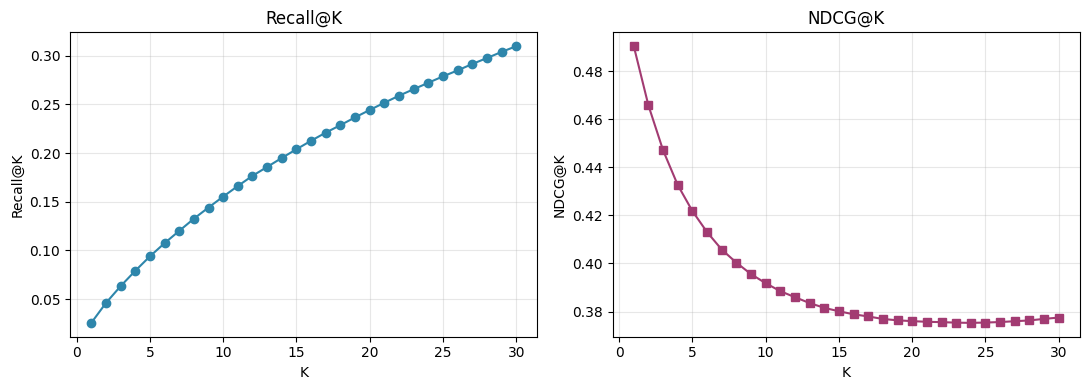

  K   Recall     NDCG
  1   0.0257   0.4904
  2   0.0461   0.4657
  3   0.0633   0.4471
  4   0.0791   0.4326
  5   0.0940   0.4218
  6   0.1075   0.4131
  7   0.1201   0.4058
  8   0.1326   0.4003
  9   0.1441   0.3956
 10   0.1553   0.3918
 11   0.1662   0.3885
 12   0.1766   0.3860
 13   0.1858   0.3835
 14   0.1950   0.3816
 15   0.2039   0.3801
 16   0.2127   0.3789
 17   0.2210   0.3780
 18   0.2287   0.3769
 19   0.2366   0.3763
 20   0.2442   0.3760
 21   0.2517   0.3757
 22   0.2589   0.3756
 23   0.2656   0.3754
 24   0.2722   0.3753
 25   0.2787   0.3754
 26   0.2849   0.3756
 27   0.2914   0.3760
 28   0.2976   0.3763
 29   0.3038   0.3769
 30   0.3097   0.3775


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def evaluate_range(model, train_df, test_df, K_max=30):
    model.eval()
    with torch.no_grad():
        out   = model(train_edge_index)
        u_emb = out[:n_users].cpu()
        m_emb = out[n_users:].cpu()

    watched = train_df.groupby('user')['movie'].apply(set).to_dict()
    Ks = np.arange(1, K_max + 1)
    recalls = np.zeros((0, K_max))
    ndcgs   = np.zeros((0, K_max))

    # Precompute ideal DCG for ranks 1..K_max
    inv_log = 1.0 / np.log2(np.arange(K_max) + 2)   # shape (K_max,)
    idcg_cum = np.cumsum(inv_log)                    # idcg if all top-r are hits

    rec_list, ndcg_list = [], []

    for user, group in test_df.groupby('user'):
        true_movies = set(group['movie'].values)
        n_true = len(true_movies)
        if n_true == 0:
            continue

        scores = (u_emb[user] @ m_emb.T).numpy().copy()
        for m in watched.get(user, []):
            scores[m] = -1e9

        # Top K_max once, ordered best->worst
        top = np.argpartition(-scores, K_max)[:K_max]
        top = top[np.argsort(-scores[top])]

        # Hit vector of length K_max
        hits = np.fromiter((m in true_movies for m in top), dtype=np.float32, count=K_max)

        # Recall@K for every K: cumulative hits / n_true
        rec_k = np.cumsum(hits) / n_true

        # NDCG@K: cumulative DCG / IDCG@K (IDCG uses min(n_true, K))
        dcg_k = np.cumsum(hits * inv_log)
        ideal_len = np.minimum(n_true, Ks)          # how many ideal hits fit
        idcg_k = idcg_cum[ideal_len - 1]
        ndcg_k = np.where(idcg_k > 0, dcg_k / idcg_k, 0.0)

        rec_list.append(rec_k)
        ndcg_list.append(ndcg_k)

    recalls = np.mean(rec_list, axis=0)
    ndcgs   = np.mean(ndcg_list, axis=0)
    return Ks, recalls, ndcgs


Ks, recalls, ndcgs = evaluate_range(model, train, test, K_max=30)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ks, recalls, marker='o', color='#2E86AB')
ax[0].set_xlabel('K'); ax[0].set_ylabel('Recall@K'); ax[0].set_title('Recall@K')
ax[0].grid(alpha=0.3)

ax[1].plot(Ks, ndcgs, marker='s', color='#A23B72')
ax[1].set_xlabel('K'); ax[1].set_ylabel('NDCG@K'); ax[1].set_title('NDCG@K')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print a table too
print(f"{'K':>3} {'Recall':>8} {'NDCG':>8}")
for k, r, n in zip(Ks, recalls, ndcgs):
    print(f"{k:>3} {r:>8.4f} {n:>8.4f}")